# Benchmark set stats
Created 2025-06-06

Some basic counting of the structures and comparing if the merged tables is actually correct

Content:
1. [Count of structures](#1-count-of-structures-per-benchmark-set)
2. [Differences](#2-differences)
3. [AF2 vs AF3 stats](#3-af2-vs-af3-stats)  
    3a: [Ranking score stats](#3a-ranking-score-stats)
4. [Pearson correlation of metrics](#4-pearson-correlation-coefficients-to-rmsd_all_atom-peptide)
5. [Interface metrics normalization](#5-interface-metrics-normalizatation)
6. [Rank analyzation](#6-rank-analzyation)

### 0 Imports and Settings

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from pathlib import Path
from typing import Literal
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
# Settings

# Path to resource folder with the structures and metadata tables
path_resources = Path(r"D:\Eigene Datein\dev\Uni\JGU Bio Bachelorthesis\Daten\resources")

path_AF2 = path_resources / "AF2"
path_AF3 = path_resources / "AF3_hydrogens"
path_solved = path_resources / "solved"
path_Lee = path_resources / "benchmark set"  / "Lee et al supplemental"

In [3]:
# Load data
import load_data

dataAF2 = load_data.dataAF2(path=path_AF2 / "AF2_metrics.tsv")
dataAF3 = load_data.dataAF3(path=path_AF3 / f"{path_AF3.name}_metrics.tsv")
dataSolved = load_data.dataSolved(path=path_solved / "solved_hydrogens_metrics.tsv")
dataAF = load_data.dataAF(dataAF2, dataAF3)
print("Benchmark set")
display(dataAF)
print("Experimentally solved structures as reference")
display(dataSolved)

Benchmark set


,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2,intf_avg_plddt_rank_AF2,chainB_intf_avg_plddt_rank_AF2,pDockQ_rank_AF2,iPAE_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0,9,0,2,2,3,1,1,1,1
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0,9,0,3,1,2,2,2,2,2
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0,10,3,1,3,1,3,3,3,3
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0,2,0,4,4,4,4,4,4,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0,2,9,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,3,7,56,1,<NA>,<NA>,4,4,2,1
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,0,3,7,5,<NA>,<NA>,3,3,3,2
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,1,2,11,4,<NA>,<NA>,5,5,5,3
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,3,7,44,3,<NA>,<NA>,1,1,4,4


Experimentally solved structures as reference


,set,PDB_id,DDI_pfam_id,path,chainA_id,chainB_id,min_distance,buried_area,salt_bridges,hbonds,disulfide_bonds,hydrophobic_interactions
0,DMI,1ATP,NaN,DMI_hydrogens\1ATP_min_DMI.pdb,A,B,6.273,808.592,0,1,0,77
1,DMI,1AXC,NaN,DMI_hydrogens\1AXC_min_DMI.pdb,A,B,4.174,1209.332,0,4,0,62
2,DMI,1B72,NaN,DMI_hydrogens\1B72_min_DMI.pdb,A,B,5.182,547.149,0,1,0,36
3,DMI,1B8Q,NaN,DMI_hydrogens\1B8Q_min_DMI.pdb,A,B,4.376,871.756,0,4,0,42
4,DMI,1BXX,NaN,DMI_hydrogens\1BXX_min_DMI.pdb,A,B,4.435,783.465,0,6,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...
183,DDI,3ZNI,PF14447_PF00179,DDI_hydrogens\PF14447_PF00179_3ZNI_AC.pdb,A,C,5.268,1288.881,0,10,0,85
184,DDI,3J7Y,PF14978_PF00327,DDI_hydrogens\PF14978_PF00327_3J7Y_oZ.pdb,o,Z,4.885,2488.556,0,8,0,70
185,DDI,6D6Q,PF15985_PF10175,DDI_hydrogens\PF15985_PF10175_6D6Q_GL.pdb,G,L,3.891,3659.160,1,12,0,167
186,DDI,3KZ1,PF17838_PF00071,DDI_hydrogens\PF17838_PF00071_3KZ1_BE.pdb,B,E,5.276,1249.398,2,10,0,60


In [4]:
# Load data from the Lee 2024 paper
known_DMI_Lee = pd.read_excel(path_Lee / "44320_2023_5_moesm3_esm.xlsx", sheet_name="Minimal DMI dataset")
DMI_runs_Lee = pd.read_excel(path_Lee / "44320_2023_5_moesm4_esm.xlsx", sheet_name="AF-MMv2.2 result")
print("DMI structures in the Lee et al. (2024) paper")
display(known_DMI_Lee)
print("AlphaFold 2.2 runs by Lee et al.")
display(DMI_runs_Lee)

DMI structures in the Lee et al. (2024) paper


,dmi_type,regular_expression,pdb_id,methods,organisms,uniprot_motif,uniprot_domain,chain_motif,chain_domain,chain_motif_start,chain_motif_end,chain_domain_start,chain_domain_end,motif_secondary_structure
0,DEG_APCC_KENBOX_2,.KEN.,4GGD,mutation analysis; pull down; x-ray crystallog...,Homo sapiens,O60566,Q12834,D,B,6,10,165,476,L
1,DEG_COP1_1,"[STDE]{1,3}.{0,2}[TSDE].{2,3}VP[STDE]G{0,1}[FL...",5IGO,coimmunoprecipitation; competition binding; fl...,Homo sapiens,Q96RU8,P43254,X,D,354,361,352,675,L
2,DEG_Kelch_Keap1_1,[DNS].[DES][TNS]GE,2FLU,alanine scanning; coimmunoprecipitation; compe...,Homo sapiens,Q16236,Q14145,P,X,77,82,325,609,L
3,DEG_Kelch_Keap1_2,QD.DLGV,3WN7,alanine scanning; glutathione s tranferase tag...,Mus musculus,Q60795,Q9Z2X8,B,A,26,32,324,609,H
4,DEG_MDM2_SWIB_1,"F[^P]{3}W[^P]{2,3}[VIL]",1YCR,fluorescence polarization spectroscopy; isothe...,Homo sapiens,P04637,Q00987,B,A,19,26,30,109,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,LIG_ActinCP_TwfCPI_2,"F.[KR]P..[PAS].{0,3}[RK]",7DS2,colocalization; comigration in non denaturing ...,Mus musculus,Q91YR1,P14315,C,B,323,333,2,244,L
132,LIG_KLC1_Yacidic_2,"[ED].{0,1}[IYVLMTF]Y[LIV][DE]",6FUZ,alanine scanning; coimmunoprecipitation; fluor...,Homo sapiens,Q9UQF2,O88447,A,A,707,711,214,436,L
133,LIG_LYPXL_SIV_4,[PA]Y..[AV][^P]{3}L,2XS1,biosensor; mutation analysis; western blot; x-...,Simian immunodeficiency virus - mac K6W,P05893,Q8WUM4,B,A,44,52,2,698,H
134,TRG_DiLeu_BaEn_1,E..[^P]L[LIVM],4NEE,isothermal titration calorimetry; mutation ana...,HIV-1 M:B_HXB2R,P04601,P62744,C,D,160,165,1,142,L


AlphaFold 2.2 runs by Lee et al.


,prediction_name,chainA_length,chainB_length,model_id,model_confidence,chainA_intf_avg_plddt,chainB_intf_avg_plddt,intf_avg_plddt,pDockQ,iPAE,num_chainA_intf_res,num_chainB_intf_res,num_res_res_contact,num_atom_atom_contact,num_mutation_in_motif,label
0,DEG_APCC_KENBOX_2_4GGD,312,5,ranked_0,0.887117,96.107999,77.495999,91.454999,0.162263,3.311542,15,5,23,208,known minimal,1
1,DEG_APCC_KENBOX_2_4GGD,312,5,ranked_1,0.871984,95.793846,73.986000,89.736111,0.145001,3.395909,13,5,20,190,known minimal,1
2,DEG_APCC_KENBOX_2_4GGD,312,5,ranked_2,0.760784,95.547501,57.906001,86.585239,0.116743,6.166772,16,5,27,237,known minimal,1
3,DEG_APCC_KENBOX_2_4GGD,312,5,ranked_3,0.413662,94.646667,21.510000,76.362500,0.036380,16.713730,9,3,11,83,known minimal,1
4,DEG_APCC_KENBOX_2_4GGD,312,5,ranked_4,0.359078,94.830001,19.753333,72.307001,0.029969,18.696838,7,3,9,108,known minimal,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,TRG_PTS1_2C0L_NAKL.NAKD,305,4,ranked_0,0.877999,96.388571,74.585001,92.900000,0.234389,2.903771,21,4,31,271,1,0
2696,TRG_PTS1_2C0L_NAKL.NAKD,305,4,ranked_1,0.868754,96.614545,75.270000,93.330769,0.233830,3.026700,22,4,31,262,1,0
2697,TRG_PTS1_2C0L_NAKL.NAKD,305,4,ranked_2,0.852158,96.452917,75.197498,93.416428,0.223745,3.121255,24,4,35,272,1,0
2698,TRG_PTS1_2C0L_NAKL.NAKD,305,4,ranked_3,0.819368,95.764286,69.147499,91.505600,0.204897,4.233161,21,4,31,258,1,0


In [5]:
# Stop cell designed to crash to allow "Run All" command in Jupyter notebooks to stop here
raise Exception("STOP")

Exception: STOP

--> DDI set contains only 46 and not 48 structures

### 1 Count of structures (per benchmark set)

In [ ]:
def count_structures(df: pd.DataFrame, df_label: str, benchmark_set: str|None = None, num_mutation_in_motif: str|None = None, num_mutations: int|None = None):
    data_mask = (df["model_id"] == "ranked_0")
    label = ""
    if benchmark_set is not None:
        data_mask &= (df["benchmark_set"] == benchmark_set)
        label = benchmark_set.replace('_', ' ')
    if num_mutation_in_motif is not None:
        data_mask &= (df["num_mutation_in_motif"].astype("str") == num_mutation_in_motif)
        label = {"known minimal": "known DMI", "random minimal": "random DMI", "1": "mutations DMI (n = 1)", "2": "mutations DMI (n = 2)"}[num_mutation_in_motif]
    if num_mutations is not None:
        data_mask &= (df["num_mutations"] == num_mutations)
        label += f" (n = {num_mutations})"
    return {"df": df_label, "benchmark_set": label, "count": len(df[data_mask])}
        
count_df = []
count_df.append(count_structures(DMI_runs_Lee, "Lee et al", num_mutation_in_motif="known minimal"))
count_df.append(count_structures(DMI_runs_Lee, "Lee et al", num_mutation_in_motif="random minimal"))
count_df.append(count_structures(DMI_runs_Lee, "Lee et al", num_mutation_in_motif="1"))
count_df.append(count_structures(DMI_runs_Lee, "Lee et al", num_mutation_in_motif="2"))

for df_label, df in {"Benchmark set": dataAF, "AF2": dataAF2, "AF3": dataAF3}.items():
    count_df.append(count_structures(df, df_label, benchmark_set="known_DMI", num_mutations=None))
    count_df.append(count_structures(df, df_label, benchmark_set="random_DMI", num_mutations=None))
    count_df.append(count_structures(df, df_label, benchmark_set="mutations_DMI", num_mutations=1))
    count_df.append(count_structures(df, df_label, benchmark_set="mutations_DMI", num_mutations=2))
    count_df.append(count_structures(df, df_label, benchmark_set="known_DDI", num_mutations=None))
    count_df.append(count_structures(df, df_label, benchmark_set="random_DDI", num_mutations=None))

count_df = pd.DataFrame(count_df)
display(count_df)

,df,benchmark_set,count
0,Lee et al,known DMI,136
1,Lee et al,random DMI,136
2,Lee et al,mutations DMI (n = 1),134
3,Lee et al,mutations DMI (n = 2),134
4,Benchmark set,known DMI,136
5,Benchmark set,random DMI,136
6,Benchmark set,mutations DMI (n = 1),134
7,Benchmark set,mutations DMI (n = 2),134
8,Benchmark set,known DDI,46
9,Benchmark set,random DDI,48


* AF3 has two more known_DMI structures than AF2 / Lee

    --> Those structure have predictions in the folder, but are are not listed in the metadata table of Lee et al.

* AF3 has two less known_DDI structures than AF2 / Lee

    --> Those DDIs are listed in the AF2 metadata by Lee et al., but the structure file does not exist (see cell below)

In [ ]:
# Does every AlphaFold 2 structure in the table actually have an prediction file?
# (For AlphaFold 3 this was checked when parsing the server output)
for i, row in dataAF2[(dataAF2["model_id"] == "ranked_0")].iterrows():
    set_ = "DMI" if "DMI" in row["benchmark_set"] else "DDI"
    path = path_AF2 / set_ / row["benchmark_set"] / row["prediction_name"] / "ranked_0.pdb"
    if not path.exists():
        print(row["prediction_name"])

PF07724_PF00227_1OFH_C_resi39_resi340.H_resi1_resi172
PF14978_PF00327_3J7Y_o_resi13_resi101.Z_resi57_resi127


In [ ]:
# Does every AlphaFold 2 prediction in the folder have an entry in the table?
# (For AlphaFold 3 this was checked when parsing the server output)

print("AlphaFold 2 predictions being in the folder but not the metadata table")
for benchmark_folder in ["DMI/known_DMI", "DMI/random_DMI", "DMI/mutations_DMI", "DDI/known_DDI", "DDI/random_DDI"]:
    folder = path_AF2 / benchmark_folder
    for prediction_folder in folder.iterdir():
        if not prediction_folder.is_dir():
            continue
        prediction_name = prediction_folder.name
        if len(dataAF2[dataAF2["prediction_name"] == prediction_name]) == 0:
            print("\t", folder.name,  prediction_name)

AlphaFold 2 predictions being in the folder but not the metadata table
	 known_DMI LIG_DLG_GKlike_1_3WP0
	 known_DMI LIG_IBAR_NPY_1_2YKT
	 known_DDI PF07724_PF00227_1G4B_L_resi187_resi329.O_resi1_resi170
	 known_DDI PF14978_PF00327_5OOL_o_resi13_resi101.Z_resi57_resi127


Notice that PF07724_PF00227 appears with a different PDB ID in the table (1OFH) and the folder (1G4B). Also 5OOL has two PFAM IDs and one of them (PF14978_PF00327) is the same as 3J7Y has. Could it be, that there have been an mix up and thats why I only have 46 instead of 48 predictions? It doesn't matter, I just filter them out and work with 46

Last, test if the DMI tables from the paper supplemental is equal to the dataAF2 table I'm working with

In [ ]:
# Test if the DMI runs table by Lee et al has the same structures as my merged dataAF2 table. 
# If so, a outer merge should have no missmatches (= NaN columns)
_merged = pd.merge(
    left=dataAF2[(dataAF2["benchmark_set"].str.contains("DMI"))][["prediction_name", "model_id", "benchmark_set"]],
    right=DMI_runs_Lee[["prediction_name", "model_id", "num_mutation_in_motif", "num_mutation_in_motif"]],
    left_on=["prediction_name", "model_id"],
    right_on=["prediction_name", "model_id"],
    how="outer"
)
_merged[_merged.isna().any(axis=1)]

,prediction_name,model_id,benchmark_set,num_mutation_in_motif,num_mutation_in_motif


--> The tables are equal

### 2 Differences

As the structures count show, there can not be an 1:1 mapping between the structures in the known set and the random/mutations sets. Check this

In [ ]:
# For manual inspection define search functions

def find_in_df(ELM_instance: str|None = None, PDB_id: str|None = None, Pfam_ID: str|None = None):
    """ Search for a structure in dataAF by a PDB ID, ELM instance or Pfam ID """
    data_maskAF = (dataAF["model_id"] == "ranked_0")
    if ELM_instance is not None:
        data_maskAF &= (dataAF["ELM_instance"] == ELM_instance) | (dataAF["ELM_instance_random_paired"] == ELM_instance)
    if PDB_id is not None:
        data_maskAF &= (dataAF["PDB_id"] == PDB_id) | (dataAF["PDB_id_random_paired"] == PDB_id)
    if Pfam_ID is not None:
        data_maskAF &= (dataAF["DDI_pfam_id"] == Pfam_ID) | (dataAF["DDI_pfam_id_random_paired"] == Pfam_ID)

    display(dataAF[data_maskAF][["prediction_name", "benchmark_set", "model_id", "PDB_id", "PDB_id_random_paired", "ELM_instance", "ELM_instance_random_paired", "DDI_pfam_id", "DDI_pfam_id_random_paired"]])


def find_in_df2(ELM_instance: str|None = None, PDB_id: str|None = None, Pfam_ID: str|None = None):
    """ Search for a structure in dataAF2 and dataAF3 by a PDB ID, ELM instance or Pfam ID """
    data_maskAF2 = (dataAF2["model_id"] == "ranked_0")
    data_maskAF3 = (dataAF3["model_id"] == "ranked_0")
    if ELM_instance is not None:
        data_maskAF2 &= (dataAF2["ELM_instance"] == ELM_instance) | (dataAF2["ELM_instance_random_paired"] == ELM_instance)
        data_maskAF3 &= (dataAF3["ELM_instance"] == ELM_instance) | (dataAF3["ELM_instance_random_paired"] == ELM_instance)
    if PDB_id is not None:
        data_maskAF2 &= (dataAF2["PDB_id"] == PDB_id) | (dataAF2["PDB_id_random_paired"] == PDB_id)
        data_maskAF3 &= (dataAF3["PDB_id"] == PDB_id) | (dataAF3["PDB_id_random_paired"] == PDB_id)
    if Pfam_ID is not None:
        data_maskAF2 &= (dataAF2["DDI_pfam_id"] == Pfam_ID) | (dataAF2["DDI_pfam_id_random_paired"] == Pfam_ID)
        data_maskAF3 &= (dataAF3["DDI_pfam_id"] == Pfam_ID) | (dataAF3["DDI_pfam_id_random_paired"] == Pfam_ID)
        
    print("AlphaFold 2")
    display(dataAF2[data_maskAF2][["prediction_name", "benchmark_set", "model_id", "PDB_id", "PDB_id_random_paired", "ELM_instance", "ELM_instance_random_paired", "DDI_pfam_id", "DDI_pfam_id_random_paired"]])
    print("AlphaFold 3")
    display(dataAF3[data_maskAF3][["prediction_name", "benchmark_set", "model_id", "PDB_id", "PDB_id_random_paired", "ELM_instance", "ELM_instance_random_paired", "DDI_pfam_id", "DDI_pfam_id_random_paired"]])

First, search for ELM instances not being present in all benchmark sets

In [ ]:
# ELM Instances missing in one of the DMI sets
elm_instances_AF2 = set(dataAF2["ELM_instance"]).union(set(dataAF3["ELM_instance_random_paired"])).difference(set([np.nan]))
elm_instances_AF3 = set(dataAF3["ELM_instance"]).union(set(dataAF3["ELM_instance_random_paired"])).difference(set([np.nan]))
elm_instances = elm_instances_AF2.union(elm_instances_AF3)
df = []
for ei in elm_instances:
    known_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "known_DMI") & (dataAF2["ELM_instance"] == ei)]) > 0
    random_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "random_DMI") & ((dataAF2["ELM_instance"] == ei) | (dataAF2["ELM_instance_random_paired"] == ei))]) > 0
    mutations_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "mutations_DMI") & (dataAF2["ELM_instance"] == ei)]) > 0

    known_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "known_DMI") & (dataAF3["ELM_instance"] == ei)]) > 0
    random_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "random_DMI") & ((dataAF3["ELM_instance"] == ei) | (dataAF3["ELM_instance_random_paired"] == ei))]) > 0
    mutations_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "mutations_DMI") & (dataAF3["ELM_instance"] == ei)]) > 0
    
    df.append({"ELM_Instance": ei, "known_DMI AF2": known_DMI2, "random_DMI AF2": random_DMI2, "mutations_DMI AF2": mutations_DMI2,
               "known_DMI AF3": known_DMI3, "random_DMI AF3": random_DMI3, "mutations_DMI AF3": mutations_DMI3})
df = pd.DataFrame(df)
print("ELM instances missing in one of the DMI sets (i.e. known_DMI, random_DMI, mutations_DMI)")
df.loc[df.select_dtypes('bool').sum(axis=1).lt(6)]

ELM instances missing in one of the DMI sets (i.e. known_DMI, random_DMI, mutations_DMI)


,ELM_Instance,known_DMI AF2,random_DMI AF2,mutations_DMI AF2,known_DMI AF3,random_DMI AF3,mutations_DMI AF3
5,LIG_DLG_GKlike_1,False,True,False,True,True,False
12,LIG_OCRL_FandH_1,True,True,False,True,True,False
48,MOD_CDK_SPxK_1,False,True,False,False,True,False
52,LIG_IBAR_NPY_1,False,True,False,True,True,False
120,LIG_Sin3_1,True,True,False,True,True,False


Now search by PDB ID

In [ ]:
# PDB IDs missing in one of the DMI sets
pdb_ids1 = set(dataAF2[dataAF2["benchmark_set"].str.contains("DMI")]["PDB_id"]).union(set(dataAF2[dataAF2["benchmark_set"].str.contains("DMI")]["PDB_id_random_paired"])).difference(set([np.nan])) #AF2
pdb_ids2 = set(dataAF3[dataAF3["benchmark_set"].str.contains("DMI")]["PDB_id"]).union(set(dataAF3[dataAF3["benchmark_set"].str.contains("DMI")]["PDB_id_random_paired"])).difference(set([np.nan])) #AF3
pdb_ids = pdb_ids1.union(pdb_ids2)
df = []
for pdb_id in pdb_ids:
    known_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "known_DMI") & (dataAF2["PDB_id"] == pdb_id)]) > 0
    random_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "random_DMI") & ((dataAF2["PDB_id"] == pdb_id) | (dataAF2["PDB_id_random_paired"] == pdb_id))]) > 0
    mutations_DMI2 = len(dataAF2[(dataAF2["benchmark_set"] == "mutations_DMI") & (dataAF2["PDB_id"] == pdb_id)]) > 0

    known_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "known_DMI") & (dataAF3["PDB_id"] == pdb_id)]) > 0
    random_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "random_DMI") & ((dataAF3["PDB_id"] == pdb_id) | (dataAF3["PDB_id_random_paired"] == pdb_id))]) > 0
    mutations_DMI3 = len(dataAF3[(dataAF3["benchmark_set"] == "mutations_DMI") & (dataAF3["PDB_id"] == pdb_id)]) > 0

    solved_structure = len(dataSolved[dataSolved["PDB_id"] == pdb_id]) > 0
    
    df.append({"PDB ID": pdb_id, "known_DMI AF2": known_DMI2, "random_DMI AF2": random_DMI2, "mutations_DMI AF2": mutations_DMI2,
               "known_DMI AF3": known_DMI3, "random_DMI AF3": random_DMI3, "mutations_DMI AF3": mutations_DMI3, "solved": solved_structure})
df = pd.DataFrame(df)
print("PDB IDs missing in one of the DMI sets (i.e. known_DMI, random_DMI, mutations_DMI)")
df.loc[df.select_dtypes('bool').sum(axis=1).lt(7)]

PDB IDs missing in one of the DMI sets (i.e. known_DMI, random_DMI, mutations_DMI)


,PDB ID,known_DMI AF2,random_DMI AF2,mutations_DMI AF2,known_DMI AF3,random_DMI AF3,mutations_DMI AF3,solved
11,2YKT,False,True,False,True,True,False,True
15,1PD7,True,True,False,True,True,False,True
16,3WP0,False,True,False,True,True,False,True
28,3AA1,False,True,True,False,True,True,True
33,2V52,False,True,True,False,True,True,True
68,2CCI,False,True,False,False,True,False,False
72,2V51,True,False,False,True,False,False,True
119,3AA0,True,False,False,True,False,False,True
128,3QIS,True,True,False,True,True,False,True


Look at the 2V51/2V52 and 3A00/3AA1 pairs: They are pairs of similar structures and only one is in either set. Is an improper handling of the PDB_IDs the reason? It doesn't matter, as they are only negative references

Now for the DDI structures. First the PDB IDs again

In [ ]:
# PFAM IDs missing in one of the DDI sets
pfam_ids1 = set(dataAF2[dataAF2["benchmark_set"].str.contains("DDI")]["DDI_pfam_id"]).union(set(dataAF2[dataAF2["benchmark_set"].str.contains("DDI")]["DDI_pfam_id_random_paired"])).difference(set([np.nan])) #AF2
pfam_ids2 = set(dataAF3[dataAF3["benchmark_set"].str.contains("DDI")]["DDI_pfam_id"]).union(set(dataAF3[dataAF3["benchmark_set"].str.contains("DDI")]["DDI_pfam_id_random_paired"])).difference(set([np.nan])) #AF3
pfam_ids = pfam_ids1.union(pfam_ids2)
df = []
for pfam_id in pfam_ids2:
    known_DDI2 = len(dataAF2[(dataAF2["benchmark_set"] == "known_DDI") & (dataAF2["DDI_pfam_id"] == pfam_id)]) > 0
    random_DDI2 = len(dataAF2[(dataAF2["benchmark_set"] == "random_DDI") & ((dataAF2["DDI_pfam_id"] == pfam_id) | (dataAF2["DDI_pfam_id_random_paired"] == pfam_id))]) > 0

    known_DDI3 = len(dataAF3[(dataAF3["benchmark_set"] == "known_DDI") & (dataAF3["DDI_pfam_id"] == pfam_id)]) > 0
    random_DDI3 = len(dataAF3[(dataAF3["benchmark_set"] == "random_DDI") & ((dataAF3["DDI_pfam_id"] == pfam_id) | (dataAF3["DDI_pfam_id_random_paired"] == pfam_id))]) > 0

    solved_structure = len(dataSolved[(dataSolved["DDI_pfam_id"] == pfam_id)]) > 0
    
    df.append({"PDB ID": pfam_id, "known_DDI AF2": known_DDI2, "random_DDI AF2": random_DDI2, "known_DDI AF3": known_DDI3, "random_DDI AF3": random_DDI3, "solved": solved_structure})
df = pd.DataFrame(df)
print("Pfam IDs missing in one of the DDI sets (i.e. known_DDI, random_DDI)")
df.loc[df.select_dtypes('bool').sum(axis=1).lt(5)]

Pfam IDs missing in one of the DDI sets (i.e. known_DDI, random_DDI)


,PDB ID,known_DDI AF2,random_DDI AF2,known_DDI AF3,random_DDI AF3,solved
10,PF07724_PF00227,True,True,False,True,True
32,PF14978_PF00327,True,True,False,True,True


In [ ]:
# PDB IDs missing in one of the DDI sets
pdb_ids1 = set(dataAF2[dataAF2["benchmark_set"].str.contains("DDI")]["PDB_id"]).union(set(dataAF2[dataAF2["benchmark_set"].str.contains("DDI")]["PDB_id_random_paired"])).difference(set([np.nan])) #AF2
pdb_ids2 = set(dataAF3[dataAF3["benchmark_set"].str.contains("DDI")]["PDB_id"]).union(set(dataAF3[dataAF3["benchmark_set"].str.contains("DDI")]["PDB_id_random_paired"])).difference(set([np.nan])) #AF3
pdb_ids = pdb_ids1.union(pdb_ids2)
df = []
for pdb_id in pdb_ids:
    known_DDI2 = len(dataAF2[(dataAF2["benchmark_set"] == "known_DDI") & (dataAF2["PDB_id"] == pdb_id)]) > 0
    random_DDI2 = len(dataAF2[(dataAF2["benchmark_set"] == "random_DDI") & ((dataAF2["PDB_id"] == pdb_id) | (dataAF2["PDB_id_random_paired"] == pdb_id))]) > 0

    known_DDI3 = len(dataAF3[(dataAF3["benchmark_set"] == "known_DDI") & (dataAF3["PDB_id"] == pdb_id)]) > 0
    random_DDI3 = len(dataAF3[(dataAF3["benchmark_set"] == "random_DDI") & ((dataAF3["PDB_id"] == pdb_id) | (dataAF3["PDB_id_random_paired"] == pdb_id))]) > 0

    solved_structure = len(dataSolved[(dataSolved["PDB_id"] == pdb_id)]) > 0
    
    df.append({"PDB ID": pdb_id, "known_DDI AF2": known_DDI2, "random_DDI AF2": random_DDI2, "known_DDI AF3": known_DDI3, "random_DDI AF3": random_DDI3, "solved": solved_structure})
df = pd.DataFrame(df)
print("PDB IDs missing in one of the DDI sets (i.e. known_DDI, random_DDI)")
df.loc[df.select_dtypes('bool').sum(axis=1).lt(5)]

PDB IDs missing in one of the DDI sets (i.e. known_DDI, random_DDI)


,PDB ID,known_DDI AF2,random_DDI AF2,known_DDI AF3,random_DDI AF3,solved
12,1OFH,True,False,False,False,True
40,1G4B,False,True,False,True,False
44,3J7Y,True,False,False,False,True


In [ ]:
# The DDI solved structures are identified based on PDB ID and (!) Pfam ID. The previous cell ignored that and reported only 1G4B to have no experimentally solved structure.
# Check if this is correct by querring the pair of PDB ID and Pfam ID
print("AF2 DDI structures with no experimentally solved structure")
for i, row in dataAF2[dataAF2["benchmark_set"].str.contains("DDI") & (dataAF2["model_id"] == "ranked_0")].iterrows():
    if len(dataSolved[(dataSolved["PDB_id"] == row["PDB_id"]) & (dataSolved["DDI_pfam_id"] == row["DDI_pfam_id"])]) == 0:
        print("\t", row["DDI_pfam_id"], row["PDB_id"])

print("AF3 DDI structures with no experimentally solved structure")
for i, row in dataAF3[dataAF3["benchmark_set"].str.contains("DDI") & (dataAF3["model_id"] == "ranked_0")].iterrows():
    if len(dataSolved[(dataSolved["PDB_id"] == row["PDB_id"]) & (dataSolved["DDI_pfam_id"] == row["DDI_pfam_id"])]) == 0:
        print("\t", row["DDI_pfam_id"], row["PDB_id"])

AF2 DDI structures with no experimentally solved structure
	 PF07724_PF00227 1G4B
	 PF14978_PF00327 5OOL
AF3 DDI structures with no experimentally solved structure
	 PF07724_PF00227 1G4B
	 PF14978_PF00327 5OOL


These findings overlaps with the previously mentioned theory why I only have 46 and not 48 DDI structures. But all in all it doesn't matter, I just filter those structures out

### 3 AF2 vs AF3 stats

Calcuate the stats in the comparison between AF2 and AF3

In [ ]:
def eval_set(metric:Literal["RMSD_all_atom", "RMSD_all_atom_peptide", "RMSD_domain", "DockQ"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], rmsd_filter: float|None, violinplot: bool):
    data = {}
    def _print(benchmark_set, af_v):
        nonlocal data_mask_AF2, data_mask_AF3, metric, rank_filter
        data_mask = data_mask_AF3 if af_v == "AF3" else data_mask_AF2
        d = dataAF[(dataAF["benchmark_set"] == benchmark_set) & data_mask][metric+"_"+af_v]
        data[f"{af_v} {benchmark_set}"] = list(d)
        print(f"\t{af_v} median {benchmark_set}{(' (ranked by %s)' % rank_filter) if rank_filter else ''}: {np.nanmedian(d):1.3f}, Q1 = {np.quantile(d, q=0.25):1.3f}, Q3 = {np.quantile(d, q=0.75):1.3f}")

    data_mask_AF2 = np.full(len(dataAF), fill_value=True)
    data_mask_AF3 = np.full(len(dataAF), fill_value=True)
    if rank_filter == "best_ranked":
        data_mask_AF2 = data_mask_AF2 & (dataAF[f"score_rank"] == 1)
        data_mask_AF3 = data_mask_AF2
    elif rank_filter is not None:
        data_mask_AF2 = data_mask_AF2 & (dataAF[f"{rank_filter}_rank_AF2"] == 1)
        data_mask_AF3 = data_mask_AF3 & (dataAF[f"{rank_filter}_rank_AF3"] == 1)
    if rmsd_filter:
        data_mask_AF2 &= dataAF["RMSD_all_atom_peptide"] <= rmsd_filter
        data_mask_AF3 &= dataAF["RMSD_all_atom_peptide"] <= rmsd_filter

    
    print(f"{metric}" + (f"(RMSD <= {rmsd_filter:1.1f})" if rmsd_filter else ""))
    _print("known_DMI", "AF2")
    _print("known_DMI", "AF3")
    _print("known_DDI", "AF2")
    _print("known_DDI", "AF3")
    if violinplot:
        sns.catplot(data)
        plt.show()


In [ ]:
eval_set("RMSD_all_atom", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("DockQ", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("RMSD_all_atom_peptide", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)
eval_set("RMSD_domain", rank_filter="RMSD_peptide", rmsd_filter=False, violinplot=False)

RMSD_all_atom
	AF2 median known_DMI (ranked by RMSD_peptide): 1.913, Q1 = 1.476, Q3 = 3.234
	AF3 median known_DMI (ranked by RMSD_peptide): 1.727, Q1 = 1.165, Q3 = 2.808
	AF2 median known_DDI (ranked by RMSD_peptide): 5.623, Q1 = 1.915, Q3 = 11.584
	AF3 median known_DDI (ranked by RMSD_peptide): 4.504, Q1 = 1.945, Q3 = 10.624
DockQ
	AF2 median known_DMI (ranked by RMSD_peptide): 0.817, Q1 = 0.508, Q3 = 0.909
	AF3 median known_DMI (ranked by RMSD_peptide): 0.886, Q1 = 0.709, Q3 = 0.949
	AF2 median known_DDI (ranked by RMSD_peptide): 0.248, Q1 = 0.049, Q3 = 0.676
	AF3 median known_DDI (ranked by RMSD_peptide): 0.331, Q1 = 0.054, Q3 = 0.680
RMSD_all_atom_peptide
	AF2 median known_DMI (ranked by RMSD_peptide): 2.704, Q1 = 1.539, Q3 = 6.970
	AF3 median known_DMI (ranked by RMSD_peptide): 1.962, Q1 = 1.141, Q3 = 3.837
	AF2 median known_DDI (ranked by RMSD_peptide): 9.535, Q1 = 4.482, Q3 = 23.688
	AF3 median known_DDI (ranked by RMSD_peptide): 8.707, Q1 = 4.220, Q3 = 25.342
RMSD_domain
	AF2 m

In [ ]:
eval_set("RMSD_all_atom", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("DockQ", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("RMSD_all_atom_peptide", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)
eval_set("RMSD_domain", rank_filter="best_ranked", rmsd_filter=False, violinplot=False)

RMSD_all_atom
	AF2 median known_DMI (ranked by best_ranked): 1.979, Q1 = 1.498, Q3 = 3.553
	AF3 median known_DMI (ranked by best_ranked): 1.769, Q1 = 1.225, Q3 = 3.121
	AF2 median known_DDI (ranked by best_ranked): 6.124, Q1 = 2.218, Q3 = 15.697
	AF3 median known_DDI (ranked by best_ranked): 4.647, Q1 = 2.087, Q3 = 16.421
DockQ
	AF2 median known_DMI (ranked by best_ranked): 0.798, Q1 = 0.399, Q3 = 0.902
	AF3 median known_DMI (ranked by best_ranked): 0.855, Q1 = 0.654, Q3 = 0.944
	AF2 median known_DDI (ranked by best_ranked): 0.255, Q1 = 0.029, Q3 = 0.675
	AF3 median known_DDI (ranked by best_ranked): 0.311, Q1 = 0.024, Q3 = 0.676
RMSD_all_atom_peptide
	AF2 median known_DMI (ranked by best_ranked): 3.073, Q1 = 1.757, Q3 = 7.380
	AF3 median known_DMI (ranked by best_ranked): 2.254, Q1 = 1.349, Q3 = 5.029
	AF2 median known_DDI (ranked by best_ranked): 13.156, Q1 = 4.847, Q3 = 33.844
	AF3 median known_DDI (ranked by best_ranked): 12.109, Q1 = 5.279, Q3 = 37.097
RMSD_domain
	AF2 median know

In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
print(f"mean RMSD motif of AF2 known DMI: {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DMI: {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DMI: {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DMI: {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD: {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD: {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD: {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD: {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DMI: 6.624 +- 8.426
mean RMSD motif of AF3 known DMI: 4.671 +- 6.404
median RMSD motif of AF2 known DMI: 3.073
median RMSD motif of AF3 known DMI: 2.254
AF2 overall mean RMSD: 2.743 +- 1.789
AF3 overall mean RMSD: 2.385 +- 1.662
AF2 overall median RMSD: 1.979
AF3 overall median RMSD: 1.769


In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI")]
print(f"mean RMSD motif of AF2 known DMI (all): {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DMI (all): {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DMI (all): {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DMI (all): {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD (all): {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD (all): {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD (all): {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD (all): {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DMI (all): 8.242 +- 13.966
mean RMSD motif of AF3 known DMI (all): 5.554 +- 8.025
median RMSD motif of AF2 known DMI (all): 4.217
median RMSD motif of AF3 known DMI (all): 2.443
AF2 overall mean RMSD (all): 3.007 +- 2.692
AF3 overall mean RMSD (all): 2.636 +- 2.847
AF2 overall median RMSD (all): 2.151
AF3 overall median RMSD (all): 1.777


In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI")]
print(f"DockQ metric: {np.nanmedian(d["DockQ_AF2"]):1.3f}")

DockQ metric: 0.729


In [ ]:
# DDI
d = dataAF[(dataAF["benchmark_set"] == "known_DDI") & (dataAF["model_id"] == "ranked_0")]

print(f"mean RMSD motif of AF2 known DDI: {np.nanmean(d["RMSD_all_atom_peptide_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"mean RMSD motif of AF3 known DDI: {np.nanmean(d["RMSD_all_atom_peptide_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"median RMSD motif of AF2 known DDI: {np.nanmedian(d["RMSD_all_atom_peptide_AF2"]):1.3f}")
print(f"median RMSD motif of AF3 known DDI: {np.nanmedian(d["RMSD_all_atom_peptide_AF3"]):1.3f}")

print(f"AF2 overall mean RMSD DDI: {np.nanmean(d["RMSD_all_atom_AF2"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall mean RMSD DDI: {np.nanmean(d["RMSD_all_atom_AF3"]):1.3f} +- {np.nanstd(d["RMSD_all_atom_AF3"]):1.3f}")

print(f"AF2 overall median RMSD DDI: {np.nanmedian(d["RMSD_all_atom_AF2"]):1.3f}")
print(f"AF3 overall median RMSD DDI: {np.nanmedian(d["RMSD_all_atom_AF3"]):1.3f}")

mean RMSD motif of AF2 known DDI: 20.821 +- 19.631
mean RMSD motif of AF3 known DDI: 21.789 +- 20.178
median RMSD motif of AF2 known DDI: 13.156
median RMSD motif of AF3 known DDI: 12.109
AF2 overall mean RMSD DDI: 8.741 +- 7.529
AF3 overall mean RMSD DDI: 9.188 +- 8.414
AF2 overall median RMSD DDI: 6.124
AF3 overall median RMSD DDI: 4.647


##### 3a Ranking score stats

Just a simple evaluation what fraction_disordered values the AF3 predictions take

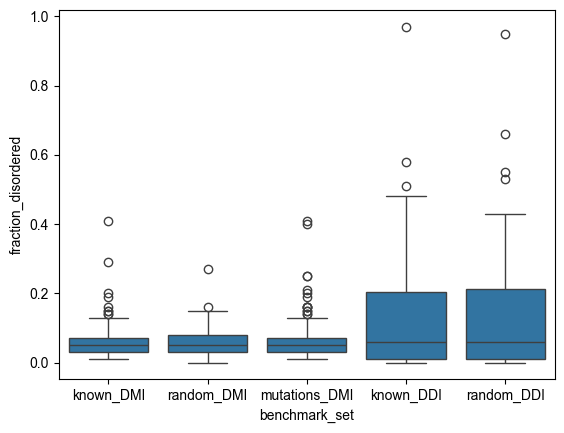

In [ ]:
def plot_af3_ranking_score_stats(model_filter: bool, save:bool):
    ax = plt.subplot()
    data_mask = np.full(len(dataAF), True)
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")


    d = {b:dataAF[(dataAF["benchmark_set"] == b) & data_mask] for b in ["known_DMI", "random_DMI", "mutations_DMI", "known_DDI", "random_DDI"]}
    #display(d)

    sns.set_theme()
    sns.boxplot(dataAF[data_mask], x="benchmark_set", y="fraction_disordered", ax=ax)
    plt.show()

plot_af3_ranking_score_stats(model_filter=True, save=False)

### 4 Pearson correlation coefficients to RMSD_all_atom peptide

Pearson correlation coefficients between various metrics and RMSD all atom peptide

In [ ]:
def get_correlation(af_v: Literal["AF2", "AF3"], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):
    data_mask = True
    if rank_filter == "best_ranked":
        data_mask = data_mask & (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        data_mask = data_mask & (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)

    def _get_corr():
        pass

    df = []
    for c in dataAF.columns:
        if not pd.api.types.is_numeric_dtype(dataAF[c].dtype):
            continue
        af_v_opposite = "AF2" if af_v == "AF3" else "AF3" 
        if af_v_opposite in c:
            continue
        d1 = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask].dropna(subset=[c, f"RMSD_all_atom_peptide_{af_v}"])
        corrDMI = None
        if len(np.unique(d1[c])) > 1:
            corrDMI = np.corrcoef(d1[f"RMSD_all_atom_peptide_{af_v}"], d1[c])[1,0]

        d2 = dataAF[(dataAF["benchmark_set"] == "known_DDI") & data_mask].dropna(subset=[c, f"RMSD_all_atom_peptide_{af_v}"])
        corrDDI = None
        if len(np.unique(d2[c])) > 1:
            corrDDI = np.corrcoef(d2[f"RMSD_all_atom_peptide_{af_v}"], d2[c])[1,0]
        df.append({"column": c, "n DMI": len(d1), "n DDI": len(d2), "DMI correlation": f"{corrDMI:1.3f}" if corrDMI is not None else None,  "DDI correlation": f"{corrDDI:1.3f}" if corrDDI is not None else None})
    return pd.DataFrame(df)
    
get_correlation("AF2", rank_filter="best_ranked")

,column,n DMI,n DDI,DMI correlation,DDI correlation
0,chainA_length,136,46,0.059,0.268
1,chainB_length,136,46,0.022,-0.019
2,chainA_start,136,46,0.084,-0.024
3,chainA_end,136,46,0.101,0.110
4,chainB_start,136,46,-0.089,-0.025
5,chainB_end,136,46,-0.089,-0.078
6,num_mutations,0,0,None,None
7,fraction_disordered,136,46,-0.086,-0.034
8,has_clash,136,46,None,None
9,iptm,136,46,-0.404,-0.609


### 5 Interface metrics: Normalizatation

Test if it helps to normalize the new interface metrics by various metrics like e.g. chain length, buried area etc. For this, calculate the AUROC with and without normalization

In [ ]:
def get_auroc_normalizations(af_v: Literal["AF2", "AF3"], row_comparison: Literal["known_DMI|mutations1_DMI", "known_DMI|mutations2_DMI", "known_DMI|random_DMI", "known_DDI|random_DDI"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):

    def _get_auroc(tr: pd.Series, fa: pd.Series, reverse: bool = False):
        y_true = [1]*len(tr) + [0]*len(fa) if not reverse else [0]*len(tr) + [1]*len(fa)
        y_score = tr.to_list() + fa.to_list()
        return roc_auc_score(y_true, y_score)
    
    def _norm_metric(rows: pd.DataFrame, metric_column: str, norm_column: str|None) -> pd.Series:
        if norm_column is None:
            return rows[metric_column].dropna()
        rows = rows.dropna(subset=[metric_column, norm_column]).copy()
        rows[norm_column] = rows[norm_column].replace(0, np.inf)
        return (rows[metric_column] / rows[norm_column]).replace([np.inf, -np.inf], 0).fillna(value=0)
        
    
    metric_columns = [("Interface distance", "min_distance", "tab:blue", True),
    ("Interface area", "buried_area", "tab:orange"),
    ("Salt bridges", "salt_bridges", "tab:green"),
    ("Hydrophobic interactions", "hydrophobic_interactions", "tab:red"),
    ("Hydrogen bonds", "hbonds", "tab:purple"),
    ]

    metric_columns = [[x[0], x[1] + "_"+af_v, x[2] , x[3] if len(x) >= 4 else False] for x in metric_columns]

    rows_sets = {
        "known_DMI": dataAF[dataAF["benchmark_set"] == "known_DMI"],
        "known_DDI": dataAF[dataAF["benchmark_set"] == "known_DDI"],
        "mutations1_DMI": dataAF[dataAF["num_mutations"] == 1],
        "mutations2_DMI": dataAF[dataAF["num_mutations"] == 2],
        "random_DMI": dataAF[dataAF["benchmark_set"] == "random_DMI"],
        "random_DDI": dataAF[dataAF["benchmark_set"] == "random_DDI"],
    }
    if rank_filter == "best_ranked":
        rows_sets = {lbl: df[df["score_rank"] == 1] for lbl, df in rows_sets.items()}
    elif rank_filter is not None:
        rows_sets = {lbl: df[((df[f"{rank_filter}_rank_{af_v}"].isna()) & (df["score_rank"] == 1)) | (df[f"{rank_filter}_rank_{af_v}"] == 1)] for lbl, df in rows_sets.items()}

    df = []
    for label, metric_column, color, reverse in metric_columns[1:]:
        d = {"metric": label}
        for norm_column in [None, 
                            f"buried_area_{af_v}", 
                            f"num_chainA_intf_res_{af_v}",  
                            f"num_chainB_intf_res_{af_v}",  
                            f"num_res_res_contact_{af_v}",  
                            f"num_atom_atom_contact_{af_v}"]:
            rows_true_normed = _norm_metric(rows=rows_sets[row_comparison.split("|")[0]], metric_column=metric_column, norm_column=norm_column)
            rows_false_normed = _norm_metric(rows=rows_sets[row_comparison.split("|")[1]], metric_column=metric_column, norm_column=norm_column)
            d[norm_column] = _get_auroc(rows_true_normed, rows_false_normed, reverse=reverse)
        df.append(d)
    return pd.DataFrame(df).round(3)

In [ ]:
# AlphaFold 2
print("known_DMI vs. random_DMI (best ranked) AF2")
display(get_auroc_normalizations(af_v="AF2", row_comparison="known_DMI|random_DMI", rank_filter="best_ranked"))
print("known_DDI vs. random_DDI (best ranked) AF2")
display(get_auroc_normalizations(af_v="AF2", row_comparison="known_DDI|random_DDI", rank_filter="best_ranked"))

known_DMI vs. random_DMI (best ranked) AF2


,metric,None,buried_area_AF2,num_chainA_intf_res_AF2,num_chainB_intf_res_AF2,num_res_res_contact_AF2,num_atom_atom_contact_AF2
0,Interface area,0.625,0.500,0.431,0.563,0.341,0.331
1,Salt bridges,0.581,0.572,0.564,0.578,0.564,0.565
2,Hydrophobic interactions,0.647,0.604,0.589,0.615,0.567,0.539
3,Hydrogen bonds,0.671,0.627,0.608,0.634,0.596,0.580


known_DDI vs. random_DDI (best ranked) AF2


,metric,None,buried_area_AF2,num_chainA_intf_res_AF2,num_chainB_intf_res_AF2,num_res_res_contact_AF2,num_atom_atom_contact_AF2
0,Interface area,0.639,0.510,0.495,0.609,0.414,0.471
1,Salt bridges,0.593,0.551,0.556,0.567,0.546,0.537
2,Hydrophobic interactions,0.574,0.489,0.481,0.529,0.466,0.474
3,Hydrogen bonds,0.634,0.581,0.597,0.596,0.565,0.555


In [ ]:
# AlphaFold 3
print("known_DMI vs. random_DMI (best ranked) AF3")
display(get_auroc_normalizations(af_v="AF3", row_comparison="known_DMI|random_DMI", rank_filter="best_ranked"))
print("known_DDI vs. random_DDI (best ranked) AF3")
display(get_auroc_normalizations(af_v="AF3", row_comparison="known_DDI|random_DDI", rank_filter="best_ranked"))

known_DMI vs. random_DMI (best ranked) AF3


,metric,None,buried_area_AF3,num_chainA_intf_res_AF3,num_chainB_intf_res_AF3,num_res_res_contact_AF3,num_atom_atom_contact_AF3
0,Interface area,0.545,0.500,0.439,0.508,0.426,0.364
1,Salt bridges,0.568,0.569,0.560,0.570,0.566,0.562
2,Hydrophobic interactions,0.601,0.590,0.583,0.581,0.574,0.541
3,Hydrogen bonds,0.673,0.672,0.662,0.662,0.665,0.653


known_DDI vs. random_DDI (best ranked) AF3


,metric,None,buried_area_AF3,num_chainA_intf_res_AF3,num_chainB_intf_res_AF3,num_res_res_contact_AF3,num_atom_atom_contact_AF3
0,Interface area,0.591,0.500,0.499,0.591,0.397,0.431
1,Salt bridges,0.521,0.488,0.493,0.490,0.478,0.472
2,Hydrophobic interactions,0.647,0.651,0.651,0.663,0.650,0.646
3,Hydrogen bonds,0.648,0.618,0.616,0.626,0.599,0.591


### 6 Rank analzyation

For AlphaFold 2, it is good practice to use the model confidence to rank predictions. But it remains to be tested if the same is true for AlphaFold 3. For this, the following section ranks the predictions based on various columns and calculates statistics on them

In [14]:
def compare_ranks(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"], c1: str, c2: str):
    """
        Function used to compare the performance of a ranking metrics. Merges for each prediction the models best performing
        in terms of c1 rank and c2 rank into a single row indicated by _c1 and _c2 suffixes. 

        Args:
            af_v: AF2 or AF3
            set_: DMI or DDI
            c1, c2: The two ranking score columns
    """
    if c1 != "score_rank":
        c1 = f"{c1}_{af_v}"
    if c2 != "score_rank":
        c2 = f"{c2}_{af_v}"
    _merge = pd.merge(
        left=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        right=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        left_on=["prediction_name", "benchmark_set", c1],
        right_on=["prediction_name", "benchmark_set", c2],
        how="inner",
        suffixes=[f"_c1", f"_c2"]
    )
    return _merge[_merge[f"{c1}_c1"] == 1][["prediction_name", "benchmark_set", f"model_id_c1", f"model_id_c2", f"{c1}_c1", f"{c2}_c2", f"RMSD_all_atom_peptide_{af_v}_c1", f"RMSD_all_atom_peptide_{af_v}_c2", f"RMSD_all_atom_{af_v}_c1", f"RMSD_all_atom_{af_v}_c2", f"DockQ_{af_v}_c1", f"DockQ_{af_v}_c2"]]

def compare_best_with_worst(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"], c: str|Literal["score", "RMSD", "RMSD_peptide", "DockQ"]):
    """ Compare the best with the worst model in terms of model_confidence (AF2) or ranking_score (AF3)"""
    cc = f"{c}_rank_{af_v}" if c != "score" else f"{c}_rank"
    _merge = pd.merge(
        left=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        right=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        left_on=["prediction_name", "benchmark_set"],
        right_on=["prediction_name", "benchmark_set"],
        how="inner",
        suffixes=["_c1", "_c2"]
    )
    return _merge[(_merge[f"{cc}_c1"] == 1) & (_merge[f"{cc}_c2"] == 5)][["prediction_name", "benchmark_set", f"model_id_c1", f"model_id_c2",f"RMSD_all_atom_peptide_{af_v}_c1", f"RMSD_all_atom_peptide_{af_v}_c2", f"RMSD_all_atom_{af_v}_c1", f"RMSD_all_atom_{af_v}_c2", f"DockQ_{af_v}_c1", f"DockQ_{af_v}_c2"]]

def compare(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"], c2: Literal["RMSD", "RMSD_peptide", "DockQ"], violinplot: bool):
    """
        Calculate the median, quartile and maximum distance to the best model when using AlphaFold derived metrics like pDockQ, iPAE, pLDDT etc. 
        to find the best ranked model.

        Args:
            af_v: AF2 or AF3
            set_: DMI or DDI
            c2: Should the best performing model be determined by overall RMSD ('RMSD'), the RMSD of the motif / smaller domain ('RMSD_peptide') or by DockQ ('DockQ')
            violinplot: If True, plot the differences between best ranked and best performin model in a violin plot
    """
    match c2:
        case "RMSD": 
            cc2 = f"RMSD_all_atom_{af_v}"
            title = f"best ranked vs. best predicted model"
            y_label = "Δ RMSD [Å]"
        case "RMSD_peptide": 
            cc2 = f"RMSD_all_atom_peptide_{af_v}"
            title = f"best ranked vs. best predicted model"
            y_label = "Δ relative RMSD [Å]"
        case "DockQ": 
            cc2 = f"DockQ_{af_v}"
            title = f"best ranked vs. best predicted model"
            y_label = "Δ DockQ"

        case _: raise RuntimeError()
    print(f"{af_v} {set_} {c2}")
    d = {}
    for label, rank_column in {"ranking_score": "score_rank", "pDockQ": "pDockQ_rank", "iPAE": "iPAE_rank", "pLDDT": "intf_avg_plddt_rank"}.items():
        df = (compare_ranks(af_v=af_v, set_=set_, c1=rank_column, c2=f"{c2}_rank"))

        m = np.abs(df[f"{cc2}_c1"].to_numpy() - df[f"{cc2}_c2"].to_numpy())
        median = np.median(m)
        q3 = np.quantile(m, q=0.75)
        max = np.max(m)
        d[label] = m
        print("\t%s median Δ%s = %1.3f Å (Q3 %1.3f Å, max %1.3f Å)" % (label, c2, median, q3, max))
    delta_rmsd = compare_best_with_worst(af_v, set_, c=c2)
    delta_rmsd = delta_rmsd[f"{cc2}_c1"].to_numpy() - delta_rmsd[f"{cc2}_c2"].to_numpy()
    max = np.max(np.abs(delta_rmsd))
    q3 = np.quantile(np.abs(delta_rmsd), q=0.75)
    median = np.median(np.abs(delta_rmsd))
    print("\tΔ%s best vs. worst model median: %1.3f Å (Q3 %1.3f Å, max %1.3f Å)" % (c2, median, q3, max))
    if violinplot:
        #sns.violinplot(d, bw_adjust=0.1, cut=0)
        plt.figure(figsize=(4.5, 3.5))
        p = sns.boxplot(d, showfliers=False, width=0.4)
        p.set_xticks(range(4), ["ranking score" if af_v == "AF3" else "model\nconfidence", "pDockQ", "iPAE", "pLDDT"])
        p.set_ylabel(y_label)
        p.set_title(f"AlphaFold {af_v[2]} {set_}:\n{title}")
        plt.show()

def compare_best_with_worst_plot(set_: Literal["DMI", "DDI"], c2: Literal["RMSD", "RMSD_peptide", "DockQ"]):
    match c2:
        case "RMSD": 
            cc2 = f"RMSD_all_atom"
            title = "RMSD"
            ylabel = f"Δ RMSD [Å]"
        case "RMSD_peptide": 
            cc2 = f"RMSD_all_atom_peptide"
            title = "relative RMSD"
            ylabel = f"Δ relative RMSD [Å]"
        case "DockQ": 
            cc2 = f"DockQ"
            title = "DockQ"
            ylabel = f"Δ DockQ"
    delta_rmsd_AF2 = compare_best_with_worst("AF2", set_, c=c2)
    delta_rmsd_AF2 = np.abs(delta_rmsd_AF2[f"{cc2}_AF2_c2"].to_numpy() - delta_rmsd_AF2[f"{cc2}_AF2_c1"].to_numpy())
    delta_rmsd_AF3 = compare_best_with_worst("AF3", set_, c=c2)
    delta_rmsd_AF3 = np.abs(delta_rmsd_AF3[f"{cc2}_AF3_c2"].to_numpy() - delta_rmsd_AF3[f"{cc2}_AF3_c1"].to_numpy())
    plt.figure(figsize=(3.5,5))
    sns.violinplot([delta_rmsd_AF2, delta_rmsd_AF3], cut=0, bw_adjust=0.5, palette=["tab:green", "tab:blue"])
    af2_patch = mpatches.Patch(color='tab:green', label='AF2')
    af3_patch = mpatches.Patch(color='tab:blue', label='AF3')
    plt.legend(handles=[af2_patch, af3_patch])
    plt.ylabel(ylabel)
    plt.title(f"{set_} models:\nbest vs. worst predicted ({title})")
    plt.show()

First DMI. (Note model_confidence is wrongly labeled ranking_score)

AF2 DMI RMSD
	ranking_score median ΔRMSD = 0.047 Å (Q3 0.204 Å, max 2.929 Å)
	pDockQ median ΔRMSD = 0.056 Å (Q3 0.222 Å, max 1.812 Å)
	iPAE median ΔRMSD = 0.044 Å (Q3 0.212 Å, max 1.812 Å)
	pLDDT median ΔRMSD = 0.049 Å (Q3 0.205 Å, max 2.623 Å)
	ΔRMSD best vs. worst model median: 0.297 Å (Q3 0.714 Å, max 33.613 Å)
AF2 DMI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.092 Å (Q3 0.470 Å, max 14.374 Å)
	pDockQ median ΔRMSD_peptide = 0.108 Å (Q3 0.682 Å, max 8.588 Å)
	iPAE median ΔRMSD_peptide = 0.088 Å (Q3 0.399 Å, max 9.500 Å)
	pLDDT median ΔRMSD_peptide = 0.120 Å (Q3 0.643 Å, max 12.778 Å)
	ΔRMSD_peptide best vs. worst model median: 1.219 Å (Q3 4.181 Å, max 180.110 Å)


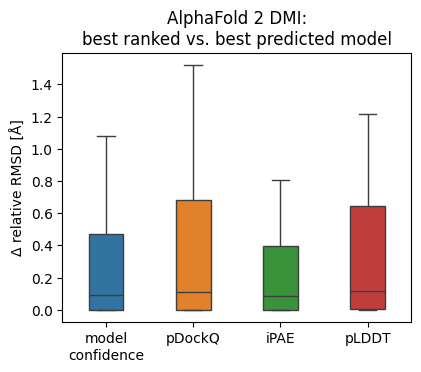

AF2 DMI DockQ
	ranking_score median ΔDockQ = 0.009 Å (Q3 0.029 Å, max 0.502 Å)
	pDockQ median ΔDockQ = 0.009 Å (Q3 0.036 Å, max 0.502 Å)
	iPAE median ΔDockQ = 0.009 Å (Q3 0.030 Å, max 0.444 Å)
	pLDDT median ΔDockQ = 0.009 Å (Q3 0.034 Å, max 0.502 Å)
	ΔDockQ best vs. worst model median: 0.061 Å (Q3 0.243 Å, max 0.900 Å)


In [18]:
compare("AF2", "DMI", "RMSD", violinplot=False)
compare("AF2", "DMI", "RMSD_peptide", violinplot=True)
compare("AF2", "DMI", "DockQ", violinplot=False)

AF3 DMI RMSD
	ranking_score median ΔRMSD = 0.074 Å (Q3 0.209 Å, max 6.342 Å)
	pDockQ median ΔRMSD = 0.078 Å (Q3 0.260 Å, max 31.304 Å)
	iPAE median ΔRMSD = 0.076 Å (Q3 0.187 Å, max 29.428 Å)
	pLDDT median ΔRMSD = 0.056 Å (Q3 0.175 Å, max 6.342 Å)
	ΔRMSD best vs. worst model median: 0.245 Å (Q3 0.776 Å, max 31.304 Å)
AF3 DMI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.171 Å (Q3 0.555 Å, max 26.521 Å)
	pDockQ median ΔRMSD_peptide = 0.229 Å (Q3 0.659 Å, max 42.647 Å)
	iPAE median ΔRMSD_peptide = 0.174 Å (Q3 0.534 Å, max 31.280 Å)
	pLDDT median ΔRMSD_peptide = 0.174 Å (Q3 0.494 Å, max 41.257 Å)
	ΔRMSD_peptide best vs. worst model median: 0.668 Å (Q3 2.161 Å, max 47.775 Å)


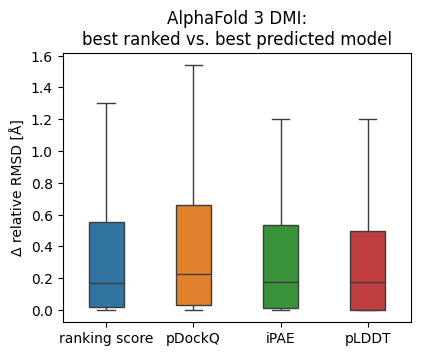

AF3 DMI DockQ
	ranking_score median ΔDockQ = 0.011 Å (Q3 0.032 Å, max 0.931 Å)
	pDockQ median ΔDockQ = 0.016 Å (Q3 0.037 Å, max 0.931 Å)
	iPAE median ΔDockQ = 0.010 Å (Q3 0.031 Å, max 0.931 Å)
	pLDDT median ΔDockQ = 0.009 Å (Q3 0.033 Å, max 0.931 Å)
	ΔDockQ best vs. worst model median: 0.045 Å (Q3 0.100 Å, max 0.952 Å)


In [15]:
compare("AF3", "DMI", "RMSD", violinplot=False)
compare("AF3", "DMI", "RMSD_peptide", violinplot=True)
compare("AF3", "DMI", "DockQ", violinplot=False)

Now DDI

AF2 DDI RMSD
	ranking_score median ΔRMSD = 0.065 Å (Q3 0.435 Å, max 16.985 Å)
	pDockQ median ΔRMSD = 0.170 Å (Q3 1.153 Å, max 22.552 Å)
	iPAE median ΔRMSD = 0.296 Å (Q3 1.425 Å, max 15.353 Å)
	pLDDT median ΔRMSD = 0.240 Å (Q3 1.854 Å, max 22.552 Å)
	ΔRMSD best vs. worst model median: 2.094 Å (Q3 7.460 Å, max 35.289 Å)
AF2 DDI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.250 Å (Q3 1.295 Å, max 46.546 Å)
	pDockQ median ΔRMSD_peptide = 0.349 Å (Q3 3.781 Å, max 49.210 Å)
	iPAE median ΔRMSD_peptide = 0.784 Å (Q3 4.715 Å, max 46.546 Å)
	pLDDT median ΔRMSD_peptide = 0.595 Å (Q3 5.238 Å, max 49.451 Å)
	ΔRMSD_peptide best vs. worst model median: 6.508 Å (Q3 27.044 Å, max 58.443 Å)


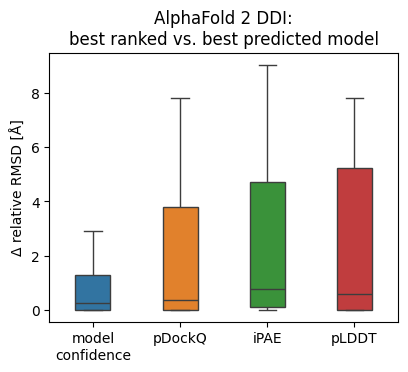

AF2 DDI DockQ
	ranking_score median ΔDockQ = 0.006 Å (Q3 0.019 Å, max 0.768 Å)
	pDockQ median ΔDockQ = 0.009 Å (Q3 0.031 Å, max 0.768 Å)
	iPAE median ΔDockQ = 0.013 Å (Q3 0.034 Å, max 0.755 Å)
	pLDDT median ΔDockQ = 0.007 Å (Q3 0.022 Å, max 0.462 Å)
	ΔDockQ best vs. worst model median: 0.041 Å (Q3 0.118 Å, max 0.816 Å)


In [16]:
compare("AF2", "DDI", "RMSD", violinplot=False)
compare("AF2", "DDI", "RMSD_peptide", violinplot=True)
compare("AF2", "DDI", "DockQ", violinplot=False)

AF3 DDI RMSD
	ranking_score median ΔRMSD = 0.375 Å (Q3 3.121 Å, max 13.243 Å)
	pDockQ median ΔRMSD = 0.363 Å (Q3 2.293 Å, max 13.243 Å)
	iPAE median ΔRMSD = 0.303 Å (Q3 1.244 Å, max 17.320 Å)
	pLDDT median ΔRMSD = 0.235 Å (Q3 1.280 Å, max 13.243 Å)
	ΔRMSD best vs. worst model median: 1.473 Å (Q3 8.847 Å, max 19.094 Å)
AF3 DDI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 1.244 Å (Q3 8.494 Å, max 23.178 Å)
	pDockQ median ΔRMSD_peptide = 0.787 Å (Q3 7.231 Å, max 48.547 Å)
	iPAE median ΔRMSD_peptide = 0.852 Å (Q3 3.227 Å, max 49.828 Å)
	pLDDT median ΔRMSD_peptide = 0.789 Å (Q3 3.227 Å, max 48.547 Å)
	ΔRMSD_peptide best vs. worst model median: 4.930 Å (Q3 14.694 Å, max 66.838 Å)


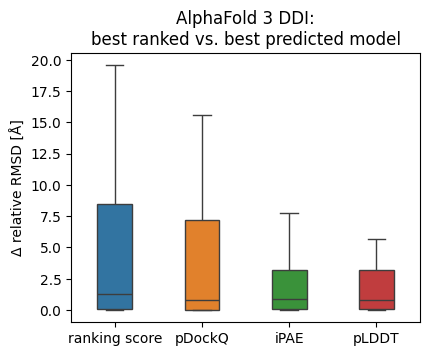

AF3 DDI DockQ
	ranking_score median ΔDockQ = 0.014 Å (Q3 0.040 Å, max 0.153 Å)
	pDockQ median ΔDockQ = 0.014 Å (Q3 0.036 Å, max 0.153 Å)
	iPAE median ΔDockQ = 0.021 Å (Q3 0.040 Å, max 0.153 Å)
	pLDDT median ΔDockQ = 0.014 Å (Q3 0.040 Å, max 0.144 Å)
	ΔDockQ best vs. worst model median: 0.051 Å (Q3 0.102 Å, max 0.778 Å)


In [17]:
compare("AF3", "DDI", "RMSD", violinplot=False)
compare("AF3", "DDI", "RMSD_peptide", violinplot=True)
compare("AF3", "DDI", "DockQ", violinplot=False)

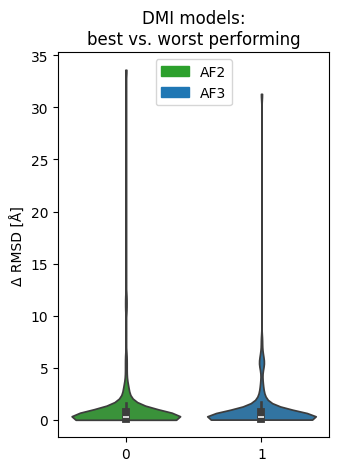

In [ ]:
compare_best_with_worst_plot(set_="DMI", c2="RMSD")

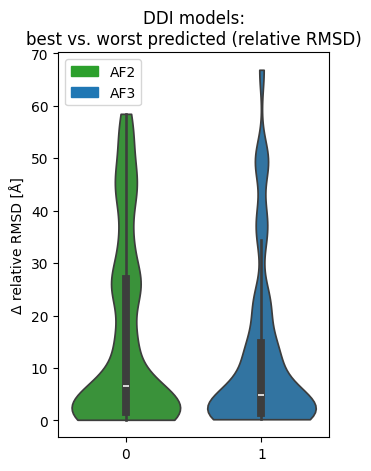

In [ ]:
compare_best_with_worst_plot(set_="DDI", c2="RMSD_peptide")